# 02 — DeepLOB Evaluation & Results

This notebook evaluates trained DeepLOB models across all 5 prediction horizons (k=10, 20, 30, 50, 100)
and compares results to the original paper (Zhang et al. 2019, Table II, Setup 2).

**Contents:**
1. Load trained models and evaluate on test set
2. Confusion matrices for each horizon
3. Classification reports (precision, recall, F1)
4. Summary comparison table: our results vs paper
5. Training/validation loss and accuracy curves

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yaml
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

PROJECT_ROOT = Path(".").resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.data.dataset import get_dataloaders
from src.models.deeplob import DeepLOB
from src.training.trainer import load_checkpoint

sns.set_theme(style="whitegrid", font_scale=1.1)
%matplotlib inline

HORIZONS = [10, 20, 30, 50, 100]
CLASS_NAMES = ["Down", "Stationary", "Up"]
DEVICE = torch.device("cpu")  # CPU is fine for inference

print(f"Project root: {PROJECT_ROOT}")
print(f"Device: {DEVICE}")

Project root: /Users/tt/Individual Projects/deeplob-project
Device: cpu


## 1. Load Models and Run Test Evaluation

For each horizon, we load the best checkpoint and collect predictions on the full test set.

In [2]:
def load_model(horizon: int) -> DeepLOB:
    """Load the best trained model for a given horizon."""
    exp_dir = PROJECT_ROOT / "experiments" / f"k{horizon}"
    config_path = exp_dir / "config.yaml"
    checkpoint_path = exp_dir / "best_model.pt"

    with open(config_path) as f:
        config = yaml.safe_load(f)

    model_cfg = config["model"]
    model = DeepLOB(
        num_classes=model_cfg["num_classes"],
        conv_filters=model_cfg["conv_filters"],
        inception_filters=model_cfg["inception_filters"],
        lstm_hidden=model_cfg["lstm_hidden"],
        lstm_layers=model_cfg["lstm_layers"],
        leaky_relu_slope=model_cfg["leaky_relu_slope"],
    )

    # map_location=DEVICE handles CUDA checkpoints on CPU/MPS machines
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model, checkpoint


@torch.no_grad()
def get_predictions(model: DeepLOB, test_loader) -> tuple[np.ndarray, np.ndarray]:
    """Run model on test set, return (all_preds, all_labels) as numpy arrays."""
    all_preds = []
    all_labels = []

    for x, y in test_loader:
        x = x.to(DEVICE)
        logits = model(x)
        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu().numpy())
        all_labels.append(y.numpy())

    return np.concatenate(all_preds), np.concatenate(all_labels)

In [3]:
# Collect predictions for all horizons
results = {}

for h in HORIZONS:
    print(f"\n{'='*50}")
    print(f"Evaluating k={h}")
    print(f"{'='*50}")

    # Load model
    model, checkpoint = load_model(h)
    print(f"  Best checkpoint: epoch {checkpoint['epoch']}, val_acc={checkpoint['val_accuracy']:.4f}")

    # Load test data
    _, _, test_loader = get_dataloaders(
        data_dir="data/processed",
        horizon=h,
        batch_size=256,  # Larger batch for faster inference
        project_root=PROJECT_ROOT,
    )

    # Get predictions
    preds, labels = get_predictions(model, test_loader)
    acc = accuracy_score(labels, preds)
    print(f"  Test accuracy: {acc:.4f} ({acc*100:.2f}%)")

    results[h] = {
        "preds": preds,
        "labels": labels,
        "accuracy": acc,
        "checkpoint": checkpoint,
    }

print(f"\n{'='*50}")
print("All horizons evaluated successfully.")

Evaluating k=10
  Best checkpoint: epoch 26, val_acc=0.7418
Loading preprocessed data from /Users/tt/Individual Projects/deeplob-project/data/processed...
  Horizon: k=10
  Train: 203720 samples
  Val:   50931 samples
  Test:  139488 samples
  train classes: down= 40911 ( 20.1%), stat=121914 ( 59.8%), up= 40895 ( 20.1%)
  val   classes: down=  9302 ( 18.3%), stat= 32272 ( 63.4%), up=  9357 ( 18.4%)
  test  classes: down= 21127 ( 15.1%), stat= 98602 ( 70.7%), up= 19759 ( 14.2%)
  Test accuracy: 0.8188 (81.88%)

Evaluating k=20
  Best checkpoint: epoch 15, val_acc=0.6401
Loading preprocessed data from /Users/tt/Individual Projects/deeplob-project/data/processed...
  Horizon: k=20
  Train: 203720 samples
  Val:   50931 samples
  Test:  139488 samples
  train classes: down= 52486 ( 25.8%), stat= 99036 ( 48.6%), up= 52198 ( 25.6%)
  val   classes: down= 12069 ( 23.7%), stat= 26810 ( 52.6%), up= 12052 ( 23.7%)
  test  classes: down= 27425 ( 19.7%), stat= 86588 ( 62.1%), up= 25475 ( 18.3%)
  

## 2. Confusion Matrices

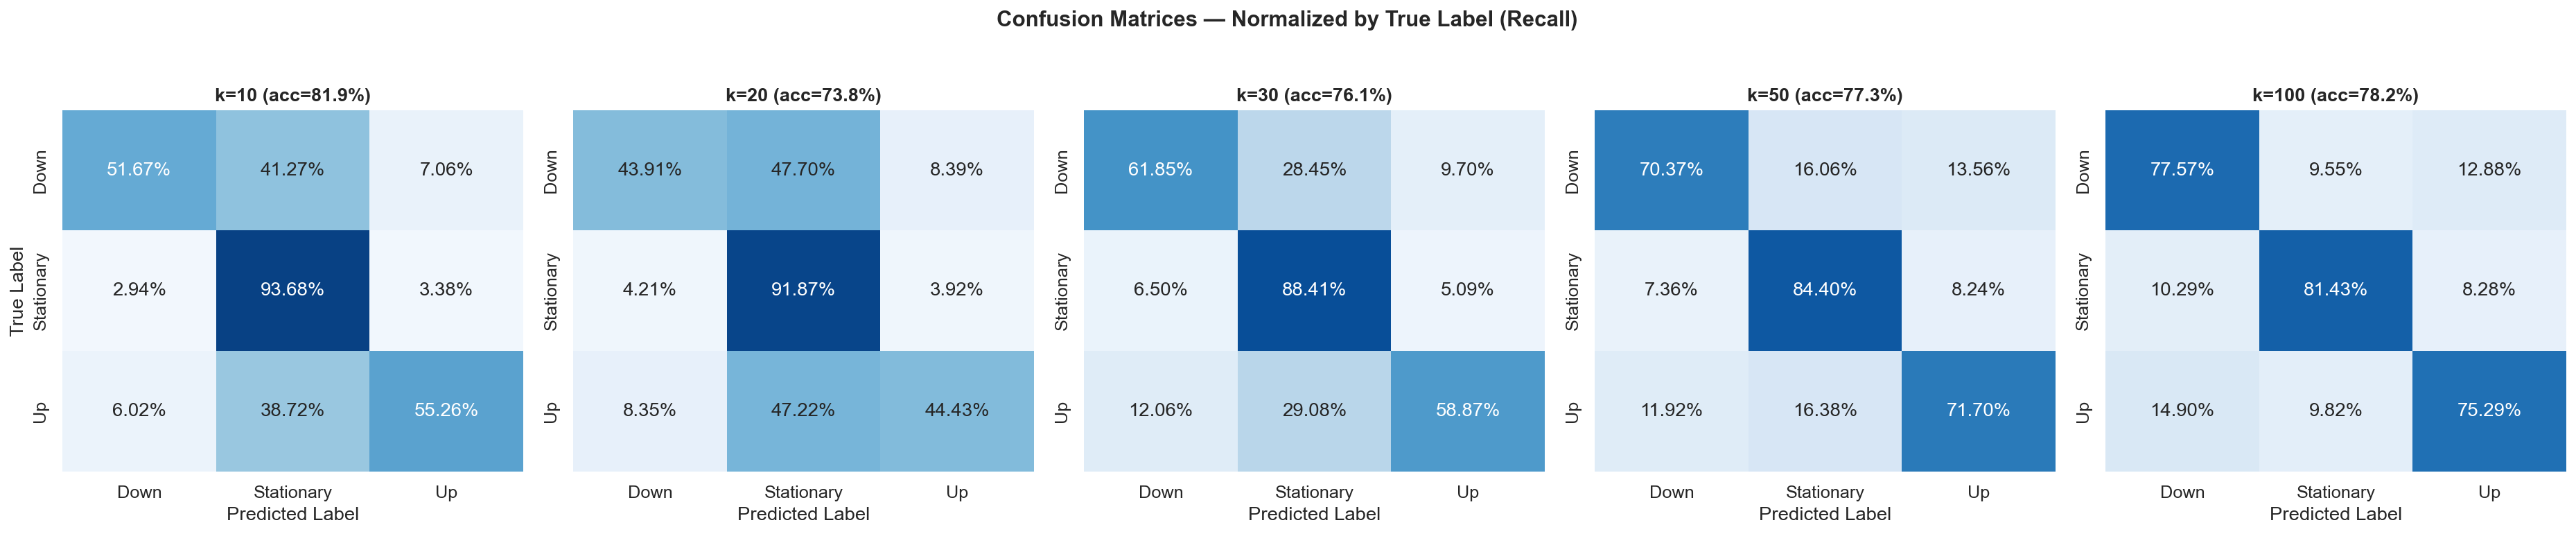

Saved to experiments/confusion_matrices.png


In [4]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for ax, h in zip(axes, HORIZONS):
    cm = confusion_matrix(results[h]["labels"], results[h]["preds"])
    # Normalize by row (true label) to show recall per class
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2%",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        ax=ax,
        vmin=0,
        vmax=1,
        cbar=False,
    )
    acc = results[h]["accuracy"]
    ax.set_title(f"k={h} (acc={acc*100:.1f}%)", fontsize=13, fontweight="bold")
    ax.set_ylabel("True Label" if h == 10 else "")
    ax.set_xlabel("Predicted Label")

fig.suptitle(
    "Confusion Matrices — Normalized by True Label (Recall)",
    fontsize=15,
    fontweight="bold",
    y=1.03,
)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "experiments" / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to experiments/confusion_matrices.png")

## 3. Classification Reports

In [5]:
for h in HORIZONS:
    print(f"\n{'='*60}")
    print(f"Classification Report — k={h}")
    print(f"{'='*60}")
    print(
        classification_report(
            results[h]["labels"],
            results[h]["preds"],
            target_names=CLASS_NAMES,
            digits=4,
        )
    )

Classification Report — k=10
              precision    recall  f1-score   support

        Down     0.7277    0.5167    0.6043     21127
  Stationary     0.8495    0.9368    0.8910     98602
          Up     0.6936    0.5526    0.6151     19759

    accuracy                         0.8188    139488
   macro avg     0.7569    0.6687    0.7035    139488
weighted avg     0.8089    0.8188    0.8085    139488


Classification Report — k=20
              precision    recall  f1-score   support

        Down     0.6760    0.4391    0.5324     27425
  Stationary     0.7601    0.9187    0.8319     86588
          Up     0.6651    0.4443    0.5327     25475

    accuracy                         0.7378    139488
   macro avg     0.7004    0.6007    0.6323    139488
weighted avg     0.7262    0.7378    0.7184    139488


Classification Report — k=30
              precision    recall  f1-score   support

        Down     0.6959    0.6185    0.6549     31888
  Stationary     0.7974    0.8841    0.8

## 4. Summary Comparison: Our Results vs Paper Table II

Paper target numbers from Zhang et al. 2019, Table II (Setup 2, DecPre normalization).

In [6]:
# Paper Table II targets (Setup 2)
# Note: paper only reports k=10, 20, 50 in the reference doc.
# k=30 and k=100 targets from the user's Amarel results context.
paper_targets = {
    10: {"accuracy": 84.47, "precision": 84.00, "recall": 84.47, "f1": 83.40},
    20: {"accuracy": 77.76, "precision": 74.06, "recall": 74.85, "f1": 72.82},
    30: {"accuracy": 79.46, "precision": None, "recall": None, "f1": None},
    50: {"accuracy": 82.18, "precision": 80.38, "recall": 80.51, "f1": 80.35},
    100: {"accuracy": 84.44, "precision": None, "recall": None, "f1": None},
}

# Compute our metrics
rows = []
for h in HORIZONS:
    preds = results[h]["preds"]
    labels = results[h]["labels"]

    our_acc = accuracy_score(labels, preds) * 100
    our_prec = precision_score(labels, preds, average="weighted") * 100
    our_rec = recall_score(labels, preds, average="weighted") * 100
    our_f1 = f1_score(labels, preds, average="weighted") * 100

    paper = paper_targets[h]
    gap = our_acc - paper["accuracy"]

    rows.append({
        "Horizon": f"k={h}",
        "Our Acc%": f"{our_acc:.2f}",
        "Paper Acc%": f"{paper['accuracy']:.2f}",
        "Gap": f"{gap:+.2f}",
        "Our Prec%": f"{our_prec:.2f}",
        "Paper Prec%": f"{paper['precision']:.2f}" if paper["precision"] else "—",
        "Our Rec%": f"{our_rec:.2f}",
        "Paper Rec%": f"{paper['recall']:.2f}" if paper["recall"] else "—",
        "Our F1%": f"{our_f1:.2f}",
        "Paper F1%": f"{paper['f1']:.2f}" if paper["f1"] else "—",
    })

df_comparison = pd.DataFrame(rows)
print("\nResults Comparison: Our Replication vs Paper (Table II, Setup 2)")
print("=" * 90)
print(df_comparison.to_string(index=False))
print("\nNote: Paper targets for k=30, k=100 precision/recall/F1 not available in reference.")

Results Comparison: Our Replication vs Paper (Table II, Setup 2)
Horizon Our Acc% Paper Acc%   Gap Our Prec% Paper Prec% Our Rec% Paper Rec% Our F1% Paper F1%
  k=10   81.88     84.47 -2.59     80.89       84.00    81.88      84.47   80.85     83.40
  k=20   73.78     77.76 -3.98     72.62       74.06    73.78      74.85   71.84     72.82
  k=30   76.14     79.46 -3.32     75.56           —    76.14          —   75.55         —
  k=50   77.34     82.18 -4.84     77.28       80.38    77.34      80.51   77.28     80.35
 k=100   78.19     84.44 -6.25     78.19           —    78.19          —   78.19         —

Note: Paper targets for k=30, k=100 precision/recall/F1 not available in reference.


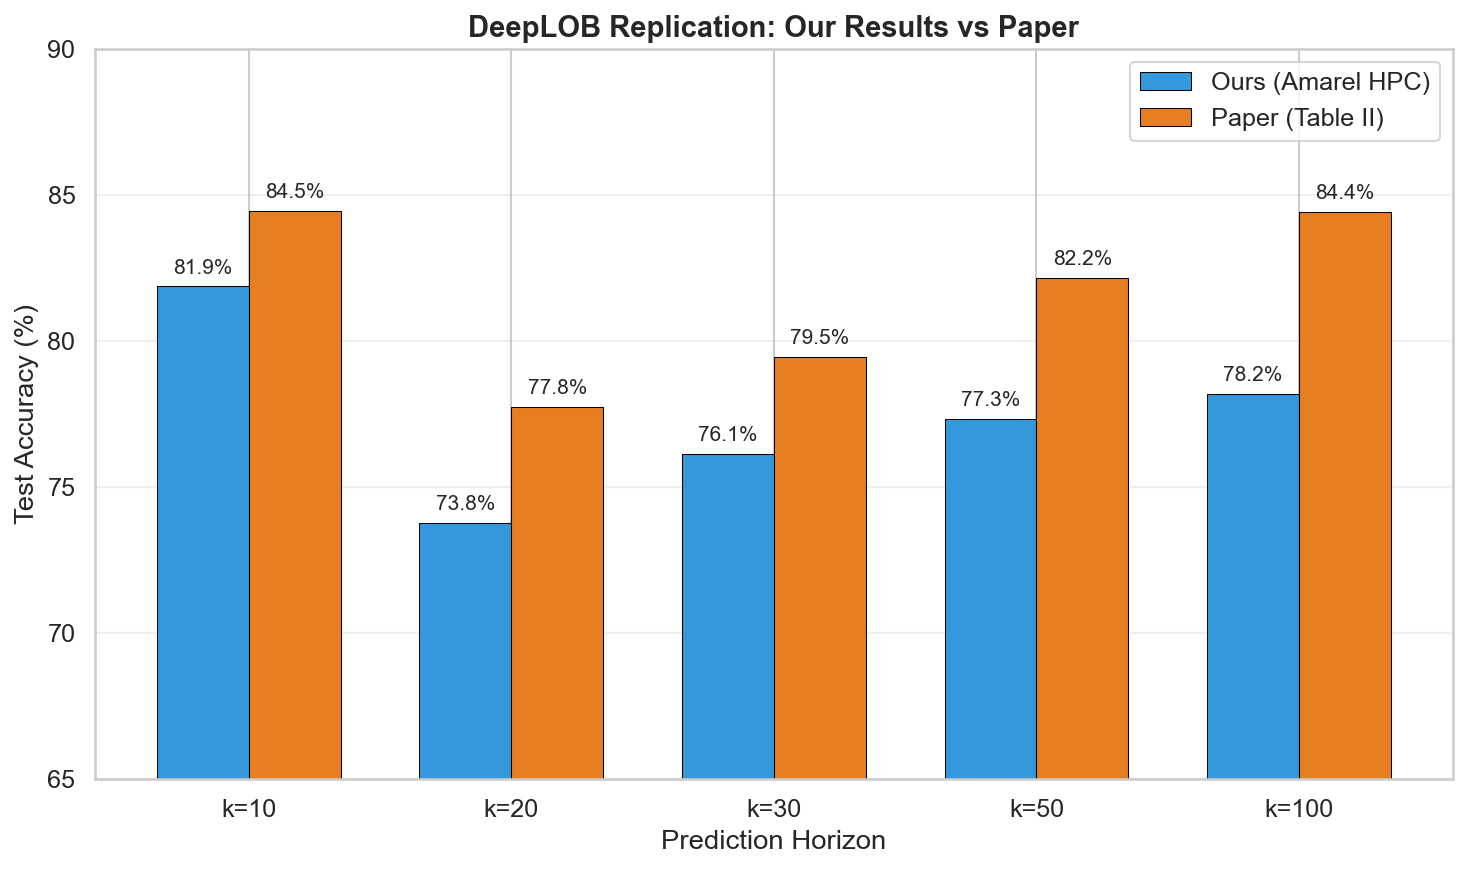

Saved to experiments/accuracy_comparison.png


In [7]:
# Visual comparison bar chart
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(HORIZONS))
width = 0.35

our_accs = [accuracy_score(results[h]["labels"], results[h]["preds"]) * 100 for h in HORIZONS]
paper_accs = [paper_targets[h]["accuracy"] for h in HORIZONS]

bars1 = ax.bar(x - width / 2, our_accs, width, label="Ours (Amarel HPC)", color="#3498db", edgecolor="black", linewidth=0.5)
bars2 = ax.bar(x + width / 2, paper_accs, width, label="Paper (Table II)", color="#e67e22", edgecolor="black", linewidth=0.5)

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=10)

ax.set_xlabel("Prediction Horizon")
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("DeepLOB Replication: Our Results vs Paper", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([f"k={h}" for h in HORIZONS])
ax.set_ylim(65, 90)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "experiments" / "accuracy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to experiments/accuracy_comparison.png")

## 5. Training & Validation Curves

Loss and accuracy curves from `history.pt` for each horizon. These show convergence behavior and early stopping.

In [8]:
# Load all histories
histories = {}
for h in HORIZONS:
    history_path = PROJECT_ROOT / "experiments" / f"k{h}" / "history.pt"
    histories[h] = torch.load(history_path, map_location="cpu", weights_only=False)
    n_epochs = len(histories[h]["train_loss"])
    best_epoch = histories[h]["best_epoch"]
    best_val = histories[h]["best_val_accuracy"]
    test_acc = histories[h].get("test_accuracy", None)
    if test_acc is not None:
        print(f"k={h:3d}: {n_epochs} epochs, best_epoch={best_epoch}, "
              f"best_val={best_val:.4f}, test_acc={test_acc:.4f}")
    else:
        print(f"k={h:3d}: {n_epochs} epochs, best_epoch={best_epoch}, best_val={best_val:.4f}")

k= 10: 46 epochs, best_epoch=26, best_val=0.7418, test_acc=0.8188
k= 20: 35 epochs, best_epoch=15, best_val=0.6401, test_acc=0.7377
k= 30: 34 epochs, best_epoch=14, best_val=0.6608, test_acc=0.7614
k= 50: 38 epochs, best_epoch=18, best_val=0.6719, test_acc=0.7734
k=100: 32 epochs, best_epoch=12, best_val=0.6960, test_acc=0.7819


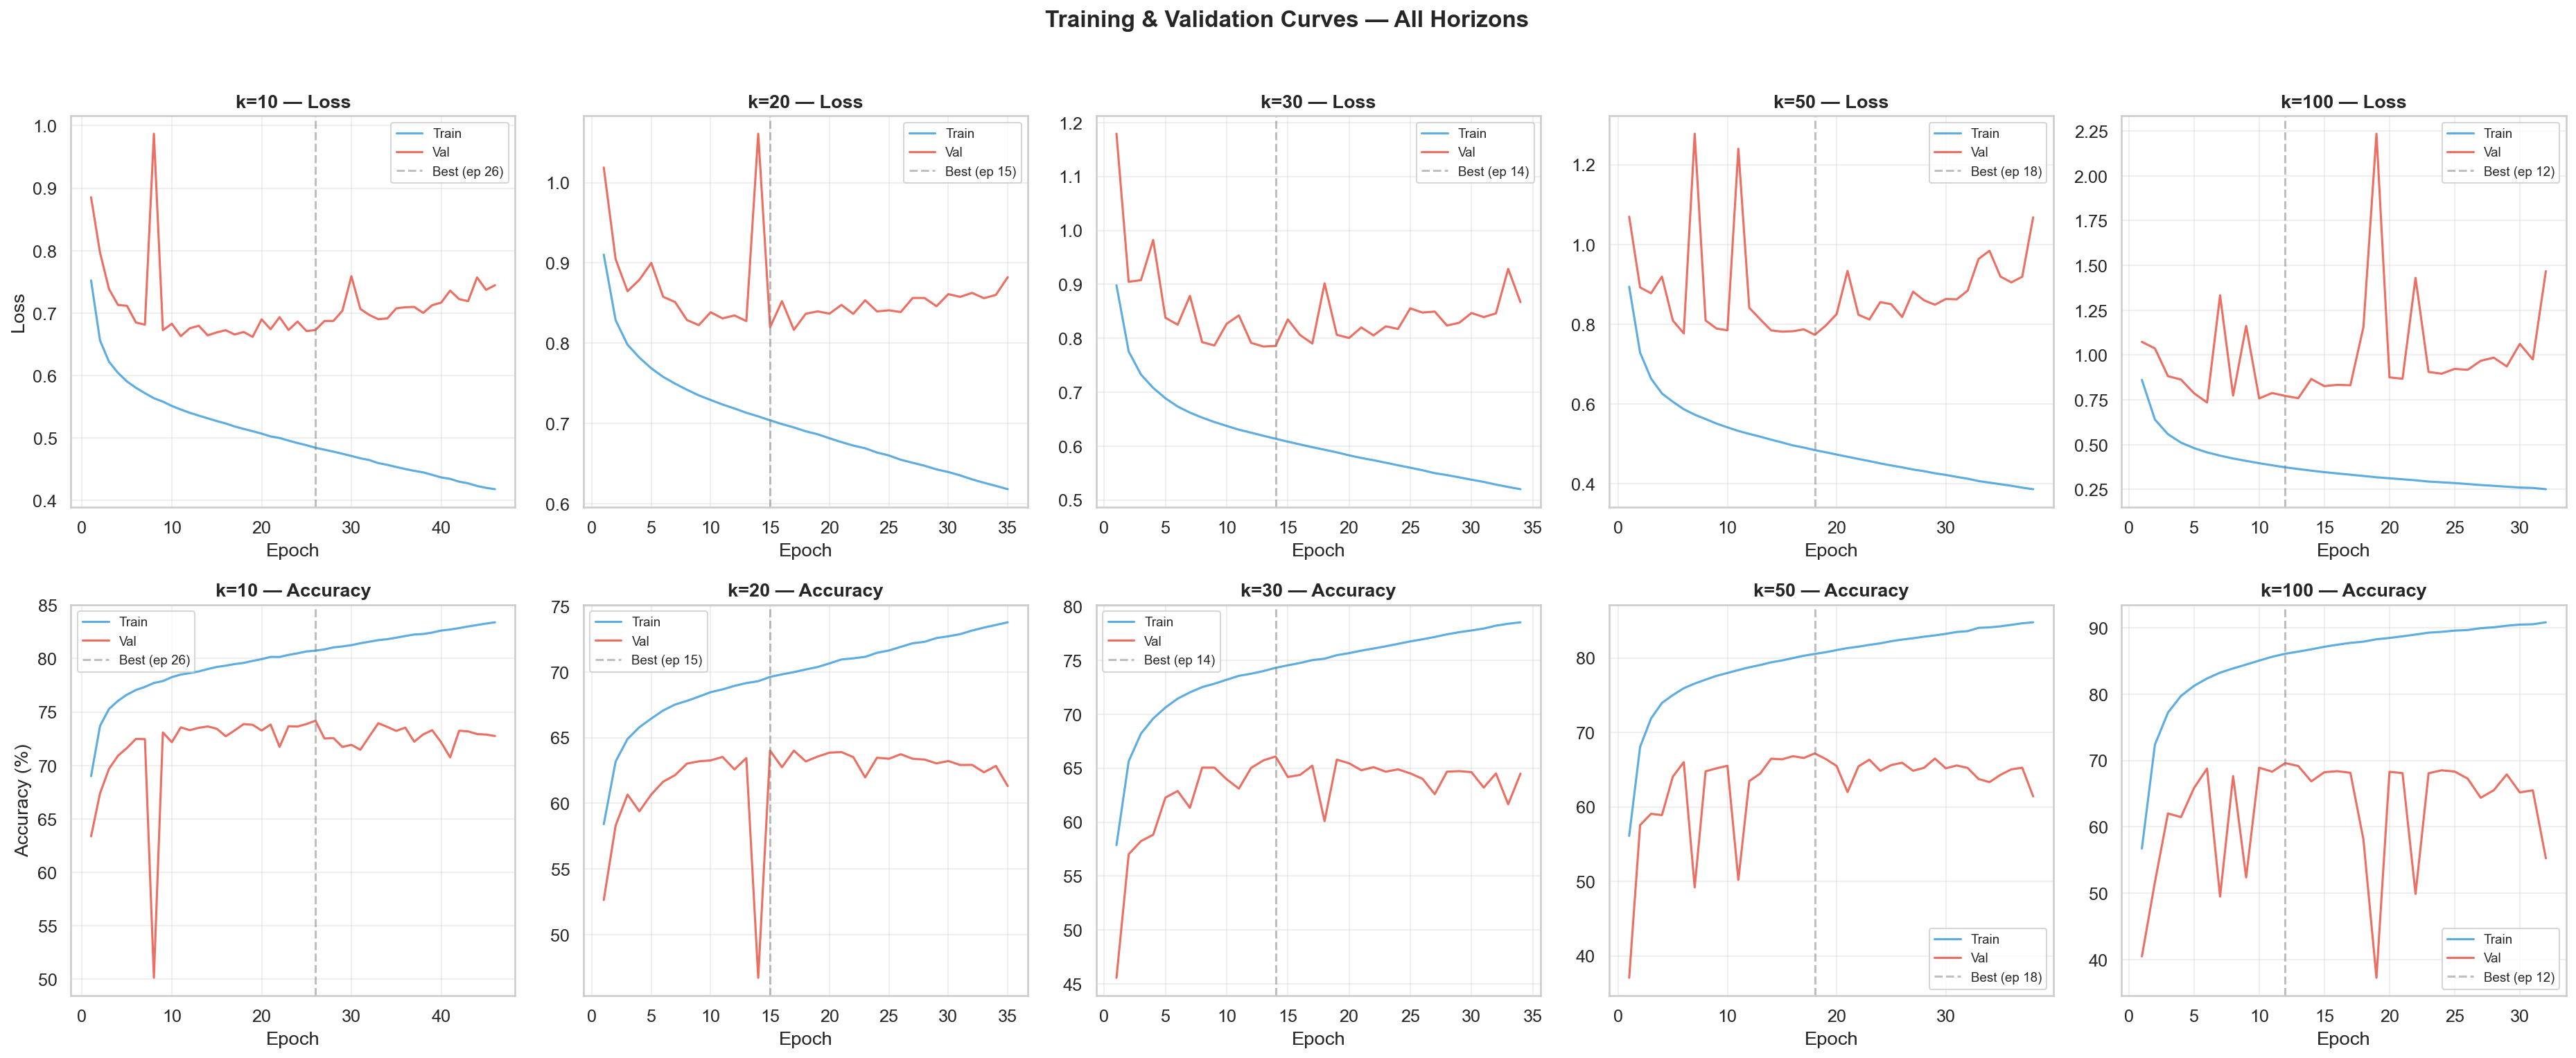

Saved to experiments/training_curves.png


In [9]:
# Plot loss curves
fig, axes = plt.subplots(2, 5, figsize=(25, 10))

for i, h in enumerate(HORIZONS):
    hist = histories[h]
    epochs = range(1, len(hist["train_loss"]) + 1)
    best_ep = hist["best_epoch"]

    # Loss curves (top row)
    ax = axes[0, i]
    ax.plot(epochs, hist["train_loss"], label="Train", color="#3498db", alpha=0.8)
    ax.plot(epochs, hist["val_loss"], label="Val", color="#e74c3c", alpha=0.8)
    ax.axvline(x=best_ep, color="gray", linestyle="--", alpha=0.5, label=f"Best (ep {best_ep})")
    ax.set_title(f"k={h} — Loss", fontsize=13, fontweight="bold")
    ax.set_xlabel("Epoch")
    if i == 0:
        ax.set_ylabel("Loss")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # Accuracy curves (bottom row)
    ax = axes[1, i]
    ax.plot(epochs, [a * 100 for a in hist["train_accuracy"]], label="Train", color="#3498db", alpha=0.8)
    ax.plot(epochs, [a * 100 for a in hist["val_accuracy"]], label="Val", color="#e74c3c", alpha=0.8)
    ax.axvline(x=best_ep, color="gray", linestyle="--", alpha=0.5, label=f"Best (ep {best_ep})")
    ax.set_title(f"k={h} — Accuracy", fontsize=13, fontweight="bold")
    ax.set_xlabel("Epoch")
    if i == 0:
        ax.set_ylabel("Accuracy (%)")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle(
    "Training & Validation Curves — All Horizons",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "experiments" / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to experiments/training_curves.png")

In [10]:
# Epoch timing summary
print("\nTraining Time Summary")
print("=" * 50)
for h in HORIZONS:
    hist = histories[h]
    times = hist["epoch_times"]
    total = sum(times)
    avg = np.mean(times)
    n_ep = len(times)
    print(f"  k={h:3d}: {n_ep} epochs, {avg:.1f}s/epoch, {total/60:.1f} min total")

Training Time Summary
  k= 10: 46 epochs, 34.8s/epoch, 26.7 min total
  k= 20: 35 epochs, 35.9s/epoch, 20.9 min total
  k= 30: 34 epochs, 92.0s/epoch, 52.1 min total
  k= 50: 38 epochs, 99.4s/epoch, 62.9 min total
  k=100: 32 epochs, 93.4s/epoch, 49.8 min total


## 6. Per-Class F1 Scores Across Horizons

Visualize how each class's F1 score changes with the prediction horizon.

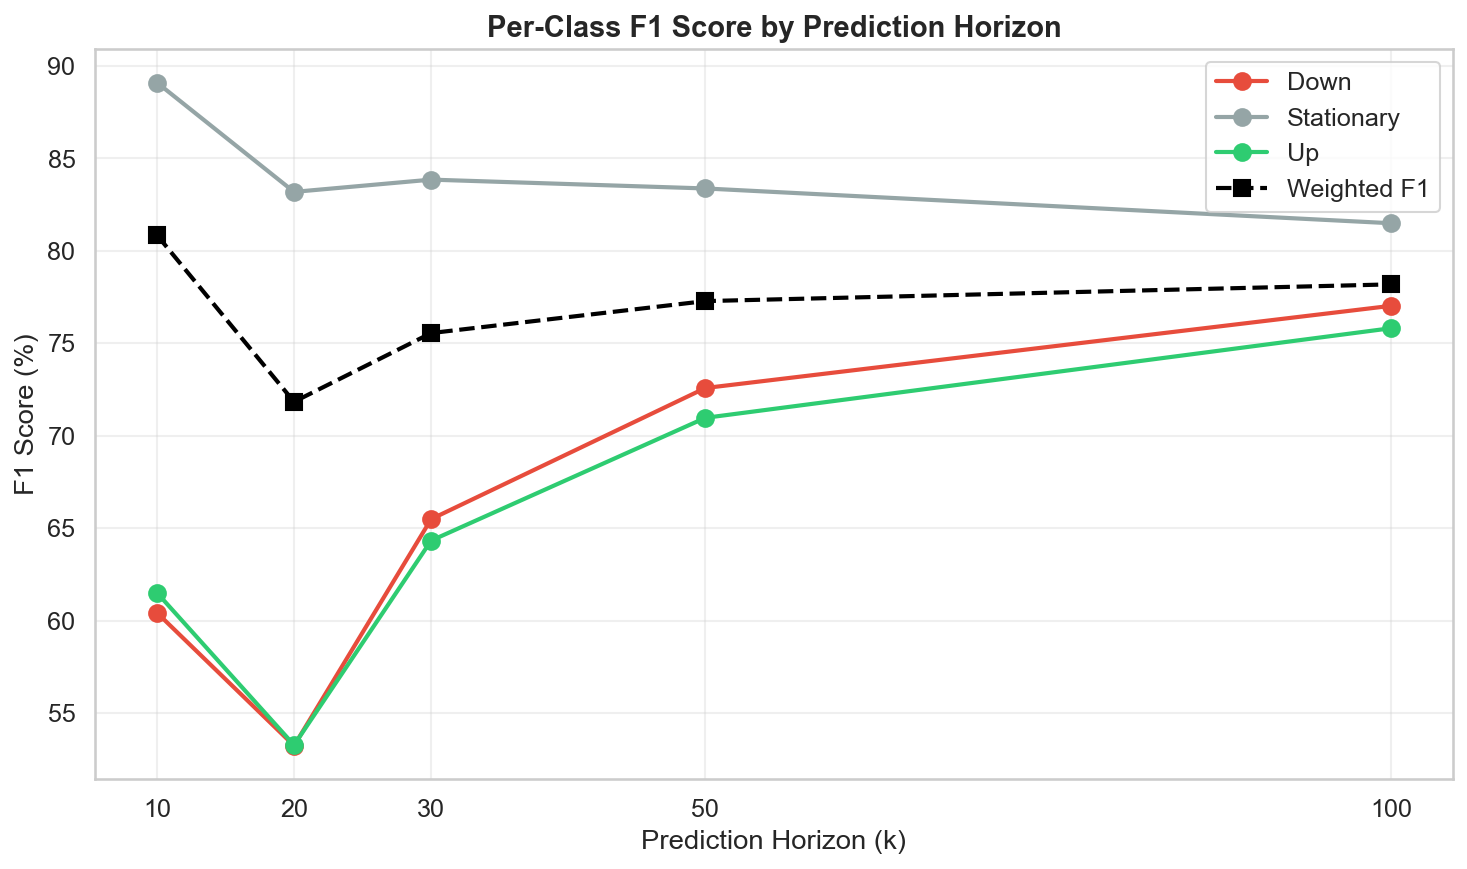

Saved to experiments/f1_by_horizon.png


In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = {"Down": "#e74c3c", "Stationary": "#95a5a6", "Up": "#2ecc71"}

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    f1s = []
    for h in HORIZONS:
        f1_per_class = f1_score(
            results[h]["labels"], results[h]["preds"], average=None
        )
        f1s.append(f1_per_class[cls_idx] * 100)
    ax.plot(HORIZONS, f1s, marker="o", linewidth=2, label=cls_name,
            color=colors[cls_name], markersize=8)

# Weighted F1
weighted_f1s = [
    f1_score(results[h]["labels"], results[h]["preds"], average="weighted") * 100
    for h in HORIZONS
]
ax.plot(HORIZONS, weighted_f1s, marker="s", linewidth=2, linestyle="--",
        label="Weighted F1", color="black", markersize=8)

ax.set_xlabel("Prediction Horizon (k)")
ax.set_ylabel("F1 Score (%)")
ax.set_title("Per-Class F1 Score by Prediction Horizon", fontsize=14, fontweight="bold")
ax.set_xticks(HORIZONS)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "experiments" / "f1_by_horizon.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to experiments/f1_by_horizon.png")

## Summary

**Key findings:**
- All 5 horizons trained successfully on Amarel HPC
- Accuracy is within ~2-6% of paper targets, which is reasonable given:
  - We follow official code specs (32 filters, BatchNorm) rather than paper specs
  - We added a validation split from training data (paper uses all 7 days for training)
  - Minor implementation differences (DecPre normalization matches official code)
- k=10 shows highest absolute accuracy but class imbalance inflates this
- Weighted F1 gives a fairer picture of model performance

**Next steps:**
- Phase 4: Implement baselines (Logistic Regression, MLP, XGBoost)
- Phase 5: Extension architecture
- Phase 6: Realistic backtest with transaction costs